<a href="https://colab.research.google.com/github/Escalada-Matthew/CPE-312/blob/main/Activity_4_1_Escalada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning and K Nearest Neighbors Exercises

## Introduction

We will be using customer churn data from the telecom industry for the first week's exercises. The data file is called
`Orange_Telecom_Churn_Data.csv`. We will load this data together, do some preprocessing, and use K-nearest neighbors to predict customer churn based on account characteristics.

In [ ]:
from __future__ import print_function
import os


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Question 1

* Begin by importing the data. Examine the columns and data.
* Notice that the data contains a state, area code, and phone number. Do you think these are good features to use when building a machine learning model? Why or why not?

We will not be using them, so they can be dropped from the data.

In [10]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/Copy of Orange_Telecom_Churn_Data.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
display(df.head())

#not gonnna be used, so they can be dropped from the data.
df_cleaned = df.drop(columns=['state', 'area_code', 'phone_number'])

Dataset Shape: (5000, 21)

Columns: ['state', 'account_length', 'area_code', 'phone_number', 'intl_plan', 'voice_mail_plan', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'number_customer_service_calls', 'churned']


,state,account_length,area_code,phone_number,intl_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,...,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churned
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


,0
state,KS
account_length,128
area_code,415
phone_number,382-4657
intl_plan,no
voice_mail_plan,yes
number_vmail_messages,25
total_day_minutes,265.1
total_day_calls,110
total_day_charge,45.07


Index(['account_length', 'intl_plan', 'voice_mail_plan',
       'number_vmail_messages', 'total_day_minutes', 'total_day_calls',
       'total_day_charge', 'total_eve_minutes', 'total_eve_calls',
       'total_eve_charge', 'total_night_minutes', 'total_night_calls',
       'total_night_charge', 'total_intl_minutes', 'total_intl_calls',
       'total_intl_charge', 'number_customer_service_calls', 'churned'],
      dtype='object')

## Question 2

* Notice that some of the columns are categorical data and some are floats. These features will need to be numerically encoded using one of the methods from the lecture.
* Finally, remember from the lecture that K-nearest neighbors requires scaled data. Scale the data using one of the scaling methods discussed in the lecture.

In [11]:
from sklearn.preprocessing import StandardScaler

df_cleaned['intl_plan'] = df_cleaned['intl_plan'].map({'yes': 1, 'no': 0})
df_cleaned['voice_mail_plan'] = df_cleaned['voice_mail_plan'].map({'yes': 1, 'no': 0})
df_cleaned['churned'] = df_cleaned['churned'].astype(int)


print("Data types after encoding:")
print(df_cleaned.dtypes)

Data types after encoding:
account_length                     int64
intl_plan                          int64
voice_mail_plan                    int64
number_vmail_messages              int64
total_day_minutes                float64
total_day_calls                    int64
total_day_charge                 float64
total_eve_minutes                float64
total_eve_calls                    int64
total_eve_charge                 float64
total_night_minutes              float64
total_night_calls                  int64
total_night_charge               float64
total_intl_minutes               float64
total_intl_calls                   int64
total_intl_charge                float64
number_customer_service_calls      int64
churned                            int64
dtype: object


## Question 3

* Separate the feature columns (everything except `churned`) from the label (`churned`). This will create two tables.
* Fit a K-nearest neighbors model with a value of `k=3` to this data and predict the outcome on the same data.

In [12]:
from sklearn.neighbors import KNeighborsClassifier


X = df_cleaned.drop(columns=['churned'])
y = df_cleaned['churned']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


knn_k3 = KNeighborsClassifier(n_neighbors=3)
knn_k3.fit(X_scaled, y)

y_pred_k3 = knn_k3.predict(X_scaled)

## Question 4

Ways to measure error haven't been discussed in class yet, but accuracy is an easy one to understand--it is simply the percent of labels that were correctly predicted (either true or false).

* Write a function to calculate accuracy using the actual and predicted labels.
* Using the function, calculate the accuracy of this K-nearest neighbors model on the data.

In [14]:
def calculate_accuracy(y_true, y_pred):
    """Calculates accuracy as the percentage of correctly predicted labels."""
    return np.mean(np.array(y_true) == np.array(y_pred))


acc_k3 = calculate_accuracy(y, y_pred_k3)
print(f"Accuracy of KNN (k=3) on training data: {acc_k3 * 100:.2f}%")

Accuracy of KNN (k=3) on training data: 93.96%


0.9422


## Question 5

* Fit the K-nearest neighbors model again with `n_neighbors=3` but this time use distance for the weights. Calculate the accuracy using the function you created above.
* Fit another K-nearest neighbors model. This time use uniform weights but set the power parameter for the Minkowski distance metric to be 1 (`p=1`) i.e. Manhattan Distance.

When weighted distances are used for part 1 of this question, a value of 1.0 should be returned for the accuracy. Why do you think this is? *Hint:* we are predicting on the data and with KNN the model *is* the data. We will learn how to avoid this pitfall in the next lecture.

In [16]:

knn_dist = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_dist.fit(X_scaled, y)
y_pred_dist = knn_dist.predict(X_scaled)
acc_dist = calculate_accuracy(y, y_pred_dist)


print(f"Accuracy (Distance-Weighted, k=3) : {acc_dist * 100:.2f}%")


Accuracy (Distance-Weighted, k=3) : 100.00%


In [17]:
knn_p1 = KNeighborsClassifier(n_neighbors=3, weights='uniform', p=1)
knn_p1.fit(X_scaled, y)
y_pred_p1 = knn_p1.predict(X_scaled)
acc_p1 = calculate_accuracy(y, y_pred_p1)

print(f"Accuracy (Manhattan Metric p=1, k=3): {acc_p1 * 100:.2f}%")

Accuracy (Manhattan Metric p=1, k=3): 94.16%


## Question 6

* Fit a K-nearest neighbors model using values of `k` (`n_neighbors`) ranging from 1 to 20. Use uniform weights (the default). The coefficient for the Minkowski distance (`p`) can be set to either 1 or 2--just be consistent. Store the accuracy and the value of `k` used from each of these fits in a list or dictionary.
* Plot (or view the table of) the `accuracy` vs `k`. What do you notice happens when `k=1`? Why do you think this is? *Hint:* it's for the same reason discussed above.

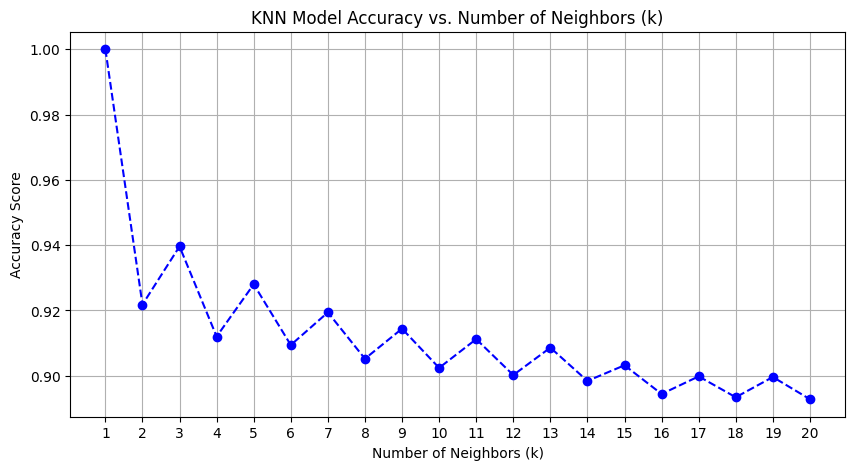

In [18]:
import matplotlib.pyplot as plt

k_range = list(range(1, 21))
accuracy_list = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
    knn.fit(X_scaled, y)
    pred = knn.predict(X_scaled)
    accuracy_list.append(calculate_accuracy(y, pred))

# Plot Accuracy vs. k
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracy_list, marker='o', linestyle='--', color='b')
plt.title('KNN Model Accuracy vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()

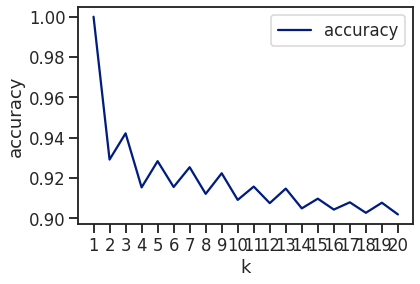

## Supplementary
1. Include Classification Report and Confusion Matrix
2. Evaluate performance of using GridSearch vs Random Search in terms of Accuracy for Training and Testing.

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler


def prepare_telecom_data(file_path="/content/Copy of Orange_Telecom_Churn_Data.csv"):

    raw_df = pd.read_csv(file_path)

    metadata_cols = ["state", "area_code", "phone_number"]
    cleaned_df = raw_df.drop(
        columns=[col for col in metadata_cols if col in raw_df.columns]
    )

    binary_mapping = {"yes": 1, "no": 0}
    for feature in ["intl_plan", "voice_mail_plan"]:
        if (
            feature in cleaned_df.columns
            and cleaned_df[feature].dtype == "object"
        ):
            cleaned_df[feature] = cleaned_df[feature].map(binary_mapping)
    cleaned_df["churned"] = cleaned_df["churned"].astype(int)


    X_data = cleaned_df.drop(columns=["churned"])
    y_data = cleaned_df["churned"]


    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.20, random_state=101, stratify=y_data
    )

    feature_scaler = StandardScaler()
    X_train_scaled = feature_scaler.fit_transform(X_train_raw)
    X_test_scaled = feature_scaler.transform(X_test_raw)

    return X_train_scaled, X_test_scaled, y_train, y_test


def run_hyperparameter_optimization(
    X_train, y_train, X_test, y_test, num_folds=5
):

    hyperparameter_grid = {
        "n_neighbors": list(range(1, 31)),
        "weights": ["uniform", "distance"],
        "p": [1, 2],  # p=1: Manhattan distance, p=2: Euclidean distance
    }

    base_knn_model = KNeighborsClassifier()

    grid_tuner = GridSearchCV(
        estimator=base_knn_model,
        param_grid=hyperparameter_grid,
        cv=num_folds,
        scoring="accuracy",
        n_jobs=-1,
    )
    grid_tuner.fit(X_train, y_train)
    best_grid_estimator = grid_tuner.best_estimator_

    random_tuner = RandomizedSearchCV(
        estimator=base_knn_model,
        param_distributions=hyperparameter_grid,
        n_iter=20,
        cv=num_folds,
        scoring="accuracy",
        random_state=101,
        n_jobs=-1,
    )
    random_tuner.fit(X_train, y_train)
    best_random_estimator = random_tuner.best_estimator_


    def evaluate_estimator(model_obj):
        tr_pred = model_obj.predict(X_train)
        te_pred = model_obj.predict(X_test)

        train_acc = accuracy_score(y_train, tr_pred)
        test_acc = accuracy_score(y_test, te_pred)
        report_dict = classification_report(y_test, te_pred, output_dict=True)
        cm_matrix = confusion_matrix(y_test, te_pred)

        return train_acc, test_acc, report_dict, cm_matrix, te_pred

    grid_tr, grid_te, grid_rep, grid_cm, grid_preds = evaluate_estimator(
        best_grid_estimator
    )
    rand_tr, rand_te, rand_rep, rand_cm, rand_preds = evaluate_estimator(
        best_random_estimator
    )

    tuning_summary = pd.DataFrame(
        [
            {
                "Search Method": "Grid Search CV",
                "Best Config": grid_tuner.best_params_,
                "Train Accuracy (%)": round(grid_tr * 100, 2),
                "Test Accuracy (%)": round(grid_te * 100, 2),
            },
            {
                "Search Method": "Randomized Search CV",
                "Best Config": random_tuner.best_params_,
                "Train Accuracy (%)": round(rand_tr * 100, 2),
                "Test Accuracy (%)": round(rand_te * 100, 2),
            },
        ]
    )

    return (
        tuning_summary,
        (grid_cm, rand_cm),
        (best_grid_estimator, best_random_estimator),
        (y_test, grid_preds, rand_preds),
    )


X_tr, X_te, y_tr, y_te = prepare_telecom_data()
summary_table, conf_matrices, estimators, predictions = (
    run_hyperparameter_optimization(X_tr, y_tr, X_te, y_te)
)

print("SEARCH METHOD COMPARISON TABLE")
print(summary_table.to_string(index=False))

print("CLASSIFICATION REPORT")
print(classification_report(y_te, predictions[1]))

print("CLASSIFICATION REPORT")
print(classification_report(y_te, predictions[2]))

SEARCH METHOD COMPARISON TABLE
       Search Method                                       Best Config  Train Accuracy (%)  Test Accuracy (%)
      Grid Search CV  {'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}                93.2               89.7
Randomized Search CV {'weights': 'distance', 'p': 1, 'n_neighbors': 6}               100.0               90.0
CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       859
           1       0.84      0.33      0.48       141

    accuracy                           0.90      1000
   macro avg       0.87      0.66      0.71      1000
weighted avg       0.89      0.90      0.88      1000

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       859
           1       0.87      0.34      0.49       141

    accuracy                           0.90      1000
   macro avg       0.89      0.67      0.72      1

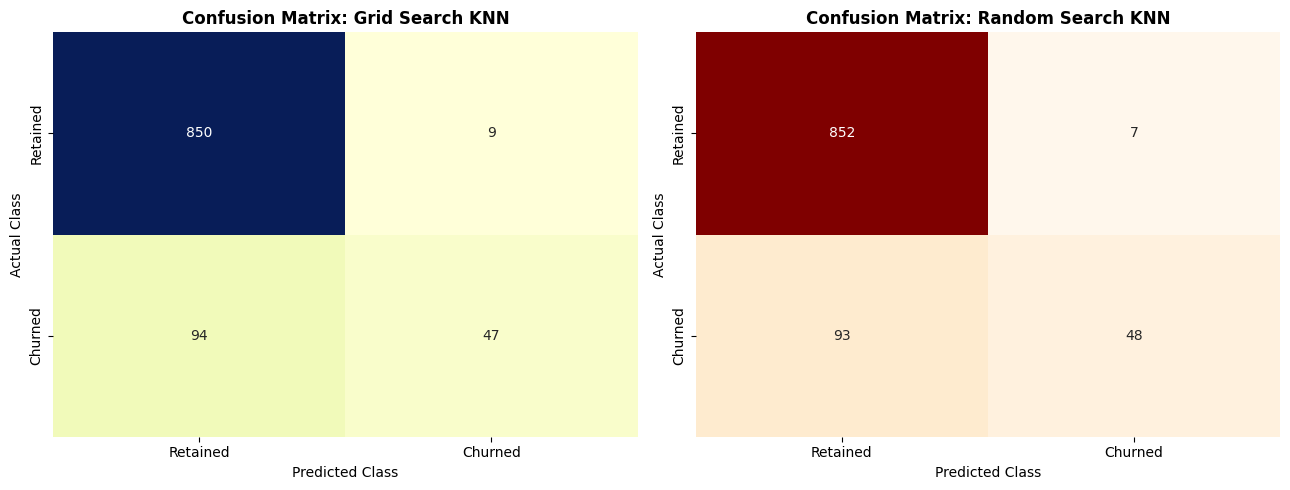

In [21]:

fig, subplots = plt.subplots(1, 2, figsize=(13, 5))


sns.heatmap(
    conf_matrices[0],
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    ax=subplots[0],
    cbar=False,
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"],
)
subplots[0].set_title(
    "Confusion Matrix: Grid Search KNN", fontsize=12, fontweight="bold"
)
subplots[0].set_xlabel("Predicted Class")
subplots[0].set_ylabel("Actual Class")

sns.heatmap(
    conf_matrices[1],
    annot=True,
    fmt="d",
    cmap="OrRd",
    ax=subplots[1],
    cbar=False,
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"],
)
subplots[1].set_title(
    "Confusion Matrix: Random Search KNN", fontsize=12, fontweight="bold"
)
subplots[1].set_xlabel("Predicted Class")
subplots[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()